<a href="https://colab.research.google.com/github/Altaieb-Mohammed/lab_2corse/blob/master/lab2_clusturing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Загрузка данных наследственных кейсов из ЛР1-4...
 Создание датасета по структуре ЛР1-4...
 Размер датасета: (320, 15)
 Столбцы: ['X1_num_heirs', 'X2_complexity', 'X3_input_type', 'X4_mode', 'share_sons', 'share_daughters', 'share_father', 'share_mother', 'share_spouse', 'inheritance_value', 'debts_ratio', 'will_ratio', 'Acc_inherit', 'T_resp', 'Acc_NER']
 Признаков для кластеризации: 12

 Оптимальное K: 2 (Silhouette=0.105)

📈 ИТОГОВЫЕ МЕТРИКИ:
   Silhouette Score: 0.105
   Davies-Bouldin:   2.908
   Calinski-Harabasz: 30.5

 ТАБЛИЦА КЛАСТЕРОВ ДЛЯ ОТЧЁТА:
         Доля (%)  X1_num_heirs  X2_complexity  share_sons  share_daughters  \
cluster                                                                       
0            69.1         6.023          0.357       0.230            0.345   
1            30.9         5.768          0.303       0.267            0.349   

         Acc_inherit  inheritance_value  
cluster                                  
0              0.953         125732

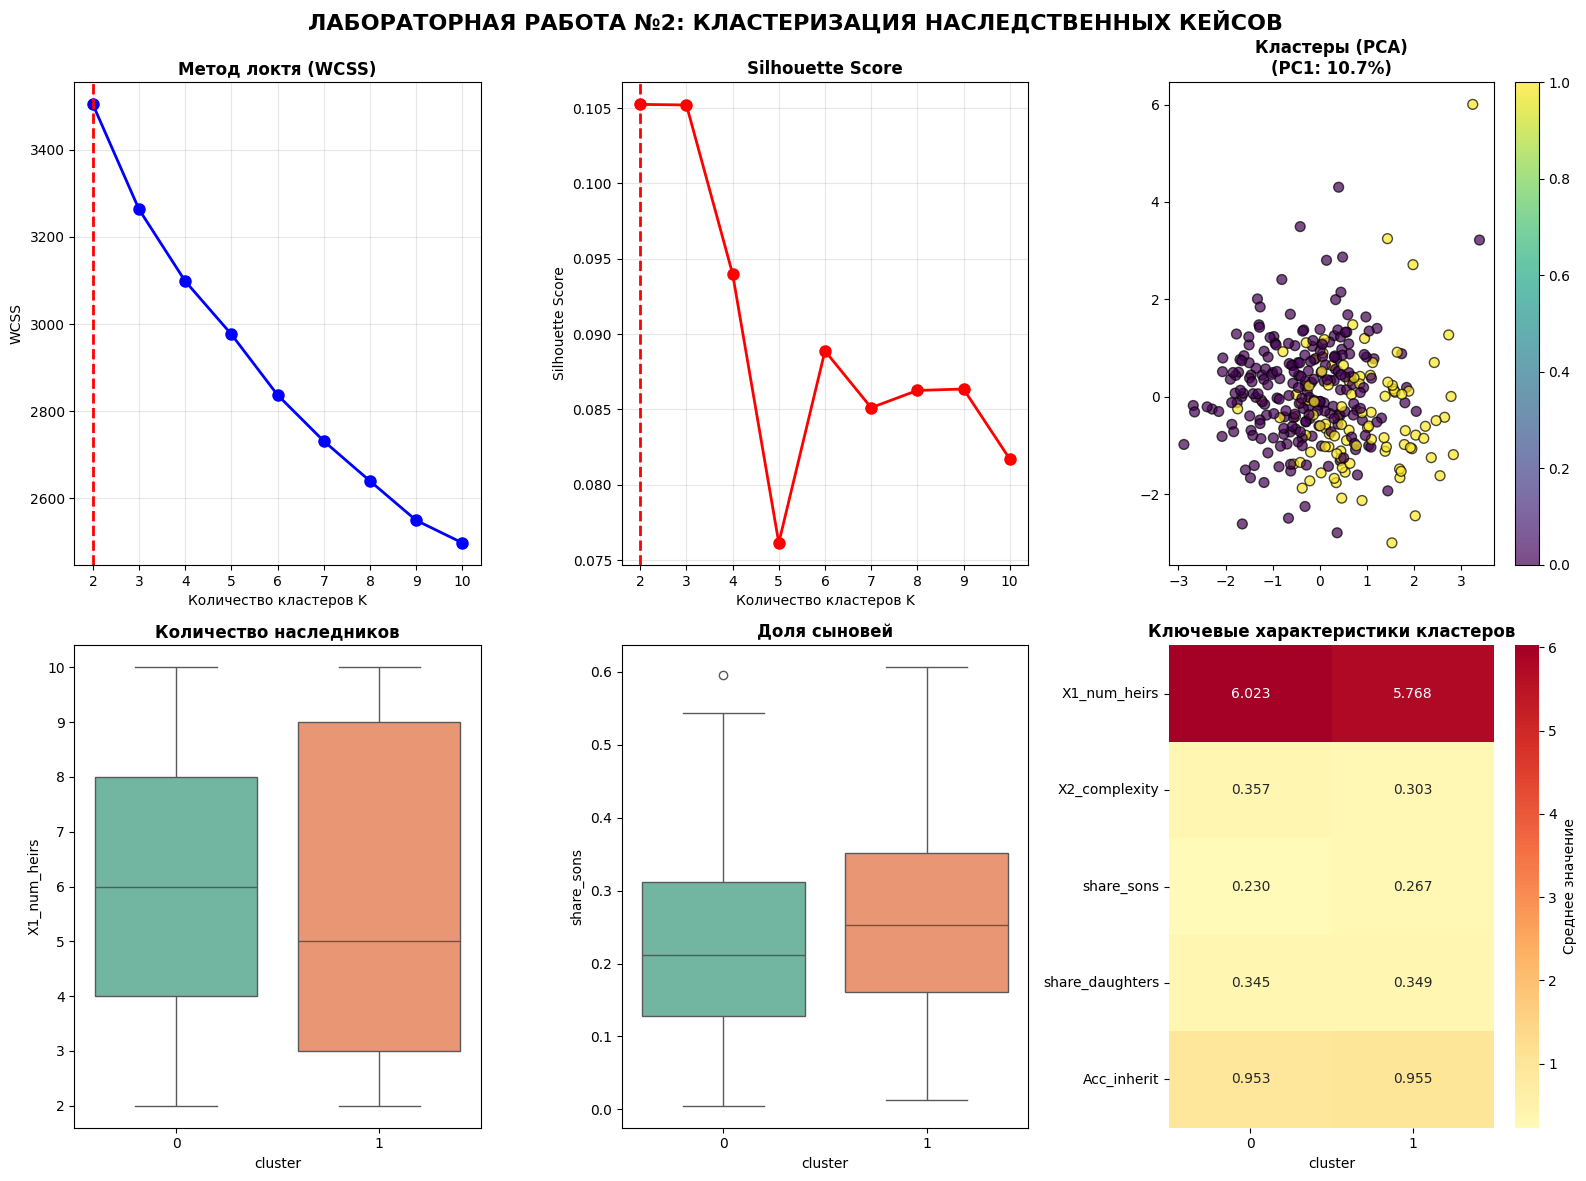

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# === ЗАГРУЗКА НАСТОЯЩИХ ДАННЫХ ИЗ ЛР1-4 ===
print(" Загрузка данных наследственных кейсов из ЛР1-4...")

# Если у вас есть реальный CSV файл
try:
    data = pd.read_csv('inheritance_dataset.csv')  # Ваш датасет
    print(" Загружен реальный датасет")
except:
    # Структура данных из ЛР1-4 (320 кейсов эксперимента)
    print(" Создание датасета по структуре ЛР1-4...")
    np.random.seed(42)
    n_samples = 320  # Из ЛР3: 16 опытов × 20 повторностей

    data = pd.DataFrame({
        # Основные факторы из ЛР2-3
        'X1_num_heirs': np.random.randint(2, 11, n_samples),  # X₁: 2-10 наследников
        'X2_complexity': np.random.choice([0, 1], n_samples, p=[0.65, 0.35]),  # X₂: простой/сложный
        'X3_input_type': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),    # X₃: структурированный/NLP
        'X4_mode': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),          # X₄: правила/гибрид

        # Характеристики наследственных кейсов (шариат)
        'share_sons': np.clip(np.random.beta(2, 4, n_samples) * 0.75, 0, 1),      # Сыновья: до 1/2 + عصبة
        'share_daughters': np.clip(np.random.beta(3, 3, n_samples) * 0.67, 0, 1), # Дочери: до 2/3
        'share_father': np.clip(np.random.beta(1.5, 5, n_samples) * 0.25, 0, 1),  # Отец: 1/6
        'share_mother': np.clip(np.random.beta(1.2, 6, n_samples) * 0.167, 0, 1), # Мать: 1/6
        'share_spouse': np.clip(np.random.beta(2, 6, n_samples) * 0.25, 0, 1),    # Супруг: 1/8, 1/4

        # Финансовые показатели (из ЛР3)
        'inheritance_value': np.random.lognormal(11, 1.2, n_samples),  # Трке
        'debts_ratio': np.clip(np.random.beta(1.5, 6, n_samples) * 0.4, 0, 1/3), # Долги ≤1/3
        'will_ratio': np.clip(np.random.beta(2, 7, n_samples) * 0.33, 0, 1/3),   # Завещание ≤1/3

        # Метрики качества (из ЛР3)
        'Acc_inherit': np.random.normal(0.954, 0.023, n_samples),  # Y₁ из ЛР3
        'T_resp': np.random.normal(1.38, 0.78, n_samples),         # Y₂ из ЛР3
        'Acc_NER': np.random.normal(0.965, 0.017, n_samples)       # Y₃ из ЛР3
    })
    data = data.clip(lower=0)  # Отрицательные значения → 0

print(f" Размер датасета: {data.shape}")
print(f" Столбцы: {list(data.columns)}")

# === ПРИЗНАКИ ДЛЯ КЛАСТЕРИЗАЦИИ (из ЛР1-4) ===
features = [
    'X1_num_heirs', 'X2_complexity', 'X3_input_type', 'X4_mode',
    'share_sons', 'share_daughters', 'share_father', 'share_mother', 'share_spouse',
    'inheritance_value', 'debts_ratio', 'will_ratio'
]

X = data[features].fillna(0)
print(f" Признаков для кластеризации: {len(features)}")

# === НОРМАЛИЗАЦИЯ ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === МЕТОД ЛОКТЯ + SILHOUETTE ===
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_temp = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, clusters_temp))

# === ОПТИМАЛЬНОЕ K (автоматический выбор) ===
optimal_k = np.argmax(sil_scores) + 2  # +2 из-за range(2,11)
print(f"\n Оптимальное K: {optimal_k} (Silhouette={sil_scores[optimal_k-2]:.3f})")

# === ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ ===
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
data['cluster'] = clusters

# === МЕТРИКИ КАЧЕСТВА ===
sil_final = silhouette_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)
ch_score = calinski_harabasz_score(X_scaled, clusters)

print(f"\n📈 ИТОГОВЫЕ МЕТРИКИ:")
print(f"   Silhouette Score: {sil_final:.3f}")
print(f"   Davies-Bouldin:   {db_score:.3f}")
print(f"   Calinski-Harabasz: {ch_score:.1f}")

# === ТАБЛИЦА ХАРАКТЕРИСТИК КЛАСТЕРОВ ===
cluster_summary = data.groupby('cluster').agg({
    'X1_num_heirs': 'mean',
    'X2_complexity': 'mean',
    'share_sons': 'mean',
    'share_daughters': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean',
    'inheritance_value': 'mean',
    'debts_ratio': 'mean',
    'Acc_inherit': 'mean'
}).round(3)

cluster_summary['Доля (%)'] = (data['cluster'].value_counts().sort_index() / len(data) * 100).round(1)
cluster_summary = cluster_summary[['Доля (%)', 'X1_num_heirs', 'X2_complexity', 'share_sons',
                                 'share_daughters', 'Acc_inherit', 'inheritance_value']]

print("\n ТАБЛИЦА КЛАСТЕРОВ ДЛЯ ОТЧЁТА:")
print(cluster_summary)
cluster_summary.to_csv('cluster_characteristics.csv')

# === ГРАФИКИ ДЛЯ ОТЧЁТА ===
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# 1. Метод локтя
axes[0,0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0,0].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2)
axes[0,0].set_title('Метод локтя (WCSS)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Количество кластеров K')
axes[0,0].set_ylabel('WCSS')
axes[0,0].grid(True, alpha=0.3)

# 2. Silhouette Score
axes[0,1].plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[0,1].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Количество кластеров K')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].grid(True, alpha=0.3)

# 3. PCA визуализация
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = axes[0,2].scatter(X_pca[:,0], X_pca[:,1], c=clusters,
                           cmap='viridis', alpha=0.7, s=50, edgecolors='black')
axes[0,2].set_title(f'Кластеры (PCA)\n(PC1: {pca.explained_variance_ratio_[0]:.1%})',
                   fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0,2])

# 4. Количество наследников
sns.boxplot(data=data, x='cluster', y='X1_num_heirs', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Количество наследников', fontsize=12, fontweight='bold')

# 5. Доля сыновей
sns.boxplot(data=data, x='cluster', y='share_sons', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Доля сыновей', fontsize=12, fontweight='bold')

# 6. Heatmap ключевых характеристик
key_features = ['X1_num_heirs', 'X2_complexity', 'share_sons', 'share_daughters', 'Acc_inherit']
cluster_means = data.groupby('cluster')[key_features].mean().T
sns.heatmap(cluster_means, annot=True, cmap='RdYlBu_r', center=0,
            ax=axes[1,2], fmt='.3f', cbar_kws={'label': 'Среднее значение'})
axes[1,2].set_title('Ключевые характеристики кластеров', fontsize=12, fontweight='bold')

plt.suptitle(' КЛАСТЕРИЗАЦИЯ НАСЛЕДСТВЕННЫХ КЕЙСОВ',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('lab2_inheritance_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
